# INAR (integer counts)

INAR — INteger-valued AutoRegression — generates *count* series: non-negative integers with autocorrelation, for demand, arrivals, and case counts where a Gaussian model makes no sense. It carries dependence forward through binomial thinning rather than a linear lag, so the output stays integer-valued.

::: {.callout-note}
## The model

$$X_t = \alpha_1 \circ X_{t-1} + \dots + \alpha_p \circ X_{t-p} + \varepsilon_t, \qquad \alpha \circ X = \sum_{i=1}^{X} \mathrm{Bernoulli}(\alpha)$$

Each step keeps a binomially-thinned fraction of the previous count and adds a fresh integer innovation. The thinning probability sets the persistence; the innovation distribution (`poisson` or `negative_binomial`) sets the marginal spread — negative binomial for overdispersion.
:::

In [ ]:
import polars as pl
import matplotlib.pyplot as plt

from synforecast.generators import INARGenerator

## 1. Innovation distribution

The innovation distribution sets the marginal spread. With the thinning parameter and innovation mean held fixed, negative binomial innovations produce overdispersion — variance above the mean — while Poisson innovations keep the two equal.


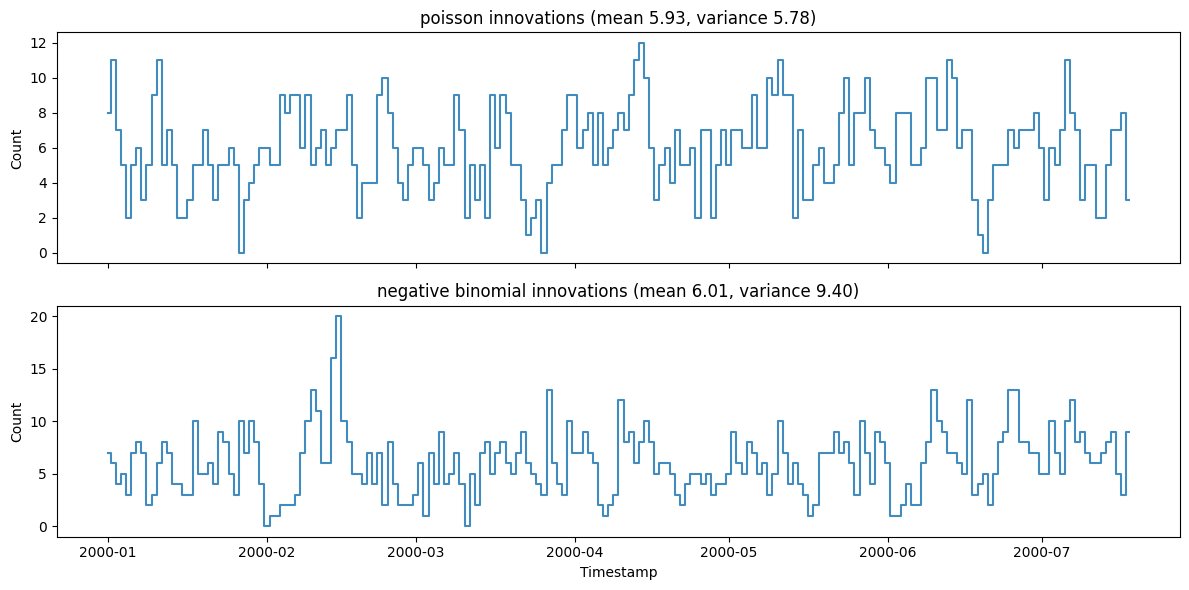

In [ ]:
poisson_df = INARGenerator(
    engine="polars",
    min_length=200,
    max_length=200,
    freq="D",
    p=1,
    alpha=[0.5],
    innovation_type="poisson",
    innovation_mean=3.0,
    seed=42,
).generate(n_series=1)

negative_binomial_df = INARGenerator(
    engine="polars",
    min_length=200,
    max_length=200,
    freq="D",
    p=1,
    alpha=[0.5],
    innovation_type="negative_binomial",
    innovation_mean=3.0,
    innovation_dispersion=2.0,
    seed=42,
).generate(n_series=1)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
panels = [("poisson", poisson_df), ("negative binomial", negative_binomial_df)]
for ax, (label, df) in zip(axes, panels):
    counts = df["y"].to_list()
    mean = sum(counts) / len(counts)
    variance = sum((count - mean) ** 2 for count in counts) / len(counts)
    ax.step(df["ds"].to_list(), counts, where="mid", alpha=0.85)
    ax.set(
        ylabel="Count",
        title=f"{label} innovations (mean {mean:.2f}, variance {variance:.2f})",
    )
axes[-1].set_xlabel("Timestamp")
plt.tight_layout()
plt.show()


## 2. Higher-order dependence

INAR(2) models have memory over two lags, producing smoother count dynamics.

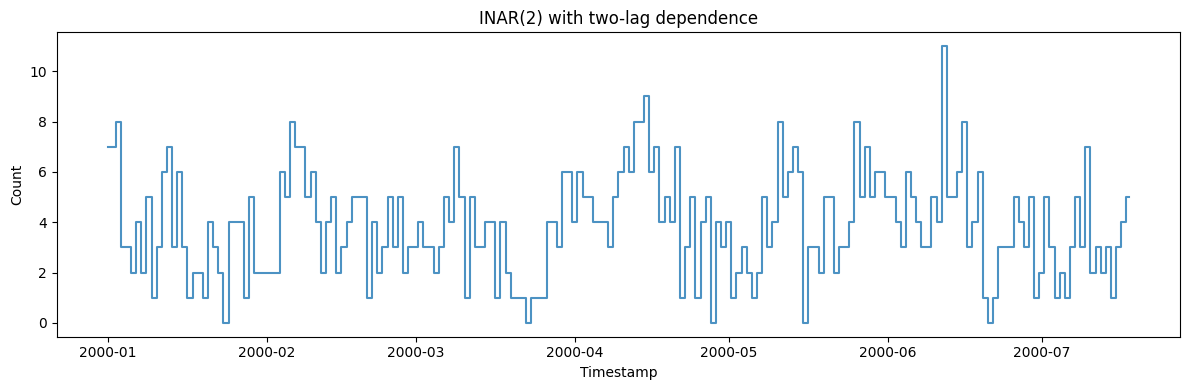

In [ ]:
inar2_gen = INARGenerator(engine="polars", 
    min_length=200,
    max_length=200,
    freq="D",
    p=2,
    alpha=[0.3, 0.2],
    innovation_type="poisson",
    innovation_mean=2.0,
    seed=42,
)
inar2_df = inar2_gen.generate(n_series=1)

fig, ax = plt.subplots(figsize=(12, 4))
ax.step(inar2_df["ds"].to_list(), inar2_df["y"].to_list(), where="mid", alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Count")
ax.set_title("INAR(2) with two-lag dependence")
plt.tight_layout()
plt.show()

## 3. Multiple series

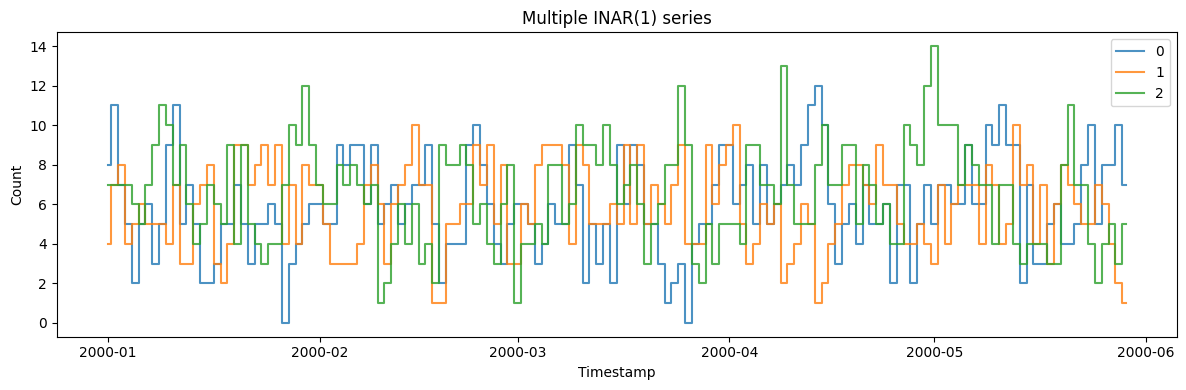

In [ ]:
multi_gen = INARGenerator(engine="polars", 
    min_length=150, max_length=150, freq="D",
    p=1, alpha=[0.5], innovation_mean=3.0, seed=42,
)
multi_df = multi_gen.generate(n_series=3)

fig, ax = plt.subplots(figsize=(12, 4))
for uid in multi_df["unique_id"].unique().to_list():
    series = multi_df.filter(pl.col("unique_id") == uid)
    ax.step(series["ds"].to_list(), series["y"].to_list(), where="mid", label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Count")
ax.set_title("Multiple INAR(1) series")
ax.legend()
plt.tight_layout()
plt.show()

::: {.callout-tip}
## Related generators

- [Intermittent demand](../domain/intermittent_demand) — sparse counts with many zeros.
- [Poisson process](../stochastic/poisson_process) — event arrivals in continuous time.

Innovation and thinning parameters are in the [generator reference](https://github.com/Nixtla/synforecast/blob/main/GENERATORS.md).
:::